# Pipeline 2: Social Media Referrals (6 Prediction Targets)

**New Dawn Safehouse Management System — Predictive ML Pipeline**

---

## Table of Contents
1. Business Understanding & Problem Definition
2. Data Understanding & Exploration
3. Data Preparation & Feature Engineering
4. Modelling — 6 Regression Models (Ch. 6–9)
5. Hyperparameter Tuning (Ch. 11)
6. Model Evaluation & Feature Importance (Ch. 12–13)
7. Lookup Table Generation
8. Deployment — CSV Output & Web Integration (Ch. 15)

## 1. Business Understanding & Problem Definition

New Dawn's social media team publishes posts across Instagram, Facebook, TikTok, LinkedIn, Twitter, and WhatsApp. Each post has controllable features (platform, media type, CTA type, content topic, boost budget, etc.) and measurable outcomes.

### Goal
Build **6 regression models** that predict post-level outcomes from controllable features:
1. `donation_referrals` — Number of donations attributed to this post
2. `estimated_donation_value_php` — Estimated total Philippine pesos (PHP) value of donations referred by this post
3. `forwards` — Number of message forwards (WhatsApp personal referrals with high donation conversion rates)
4. `profile_visits` — Number of profile visits attributed to this post
5. `engagement_rate` — Engagement rate: (likes + comments + shares) / reach
6. `impressions` — Total number of times the post was displayed

The predictions power the **Social Media Editor** page's real-time prediction cards, updating as the author changes post attributes.

### Lookup Table Design
Pre-compute predictions for all realistic feature combinations. The lookup key now includes **10 categorical dimensions**:

| Dimension | Role |
|---|---|
| platform | Core identity |
| post_type | Core identity |
| media_type | Core identity |
| content_topic | Core identity |
| sentiment_tone | Core identity |
| has_call_to_action | Derived from CTA type |
| call_to_action_type | Core identity |
| features_resident_story | Content flag |
| is_boosted | Paid promotion flag |
| **boost_budget_php_bin** | **New — bins raw budget into: none / low / medium / high** |
| day_of_week | Time dimension |

### Success Criteria
- Positive R² on cross-validation for all 6 targets
- Reasonable RMSE relative to target standard deviation
- Lookup table ≤ 50,000 rows for fast API lookups


## 2. Data Understanding & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

posts = pd.read_csv('../lighthouse_csv_v7/social_media_posts.csv')
print(f'Social media posts: {posts.shape}')
print(f'Columns: {posts.columns.tolist()}')
posts.head(3)

Social media posts: (2912, 39)
Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN


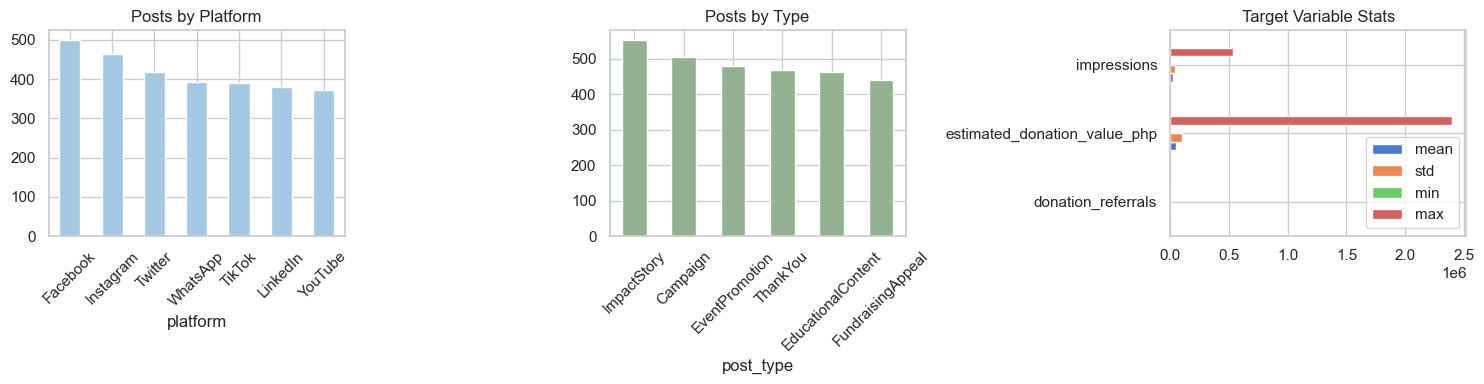

In [2]:
# Platform & post type distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

posts['platform'].value_counts().plot.bar(ax=axes[0], color='#A2C9E1')
axes[0].set_title('Posts by Platform')
axes[0].tick_params(axis='x', rotation=45)

posts['post_type'].value_counts().plot.bar(ax=axes[1], color='#91B191')
axes[1].set_title('Posts by Type')
axes[1].tick_params(axis='x', rotation=45)

targets = ['donation_referrals', 'estimated_donation_value_php', 'impressions']
for t in targets:
    posts[t] = pd.to_numeric(posts[t], errors='coerce')
posts[targets].describe().T[['mean', 'std', 'min', 'max']].plot.barh(ax=axes[2])
axes[2].set_title('Target Variable Stats')

plt.tight_layout()
plt.show()

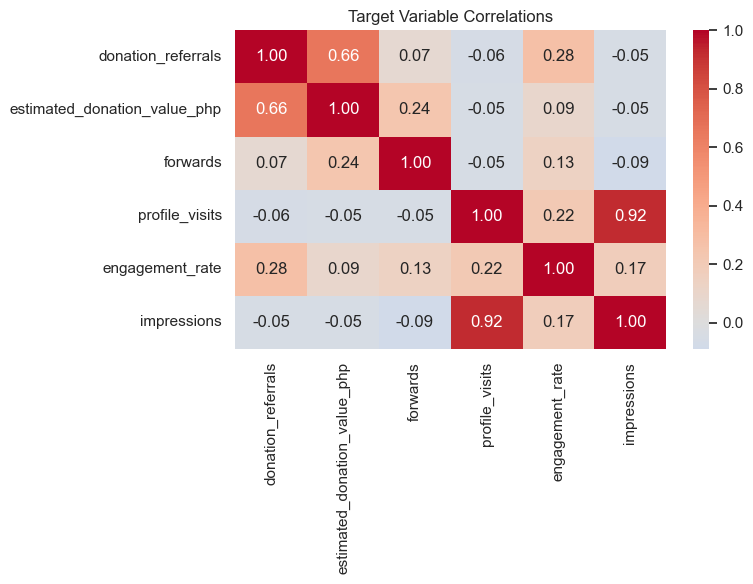

In [3]:
# Target correlations
target_cols = ['donation_referrals', 'estimated_donation_value_php', 'forwards',
               'profile_visits', 'engagement_rate', 'impressions']
for c in target_cols:
    posts[c] = pd.to_numeric(posts[c], errors='coerce').fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(posts[target_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Target Variable Correlations')
plt.tight_layout()
plt.show()

## 3. Data Preparation & Feature Engineering

We use the pipeline module's preparation functions:
- Boolean columns (`has_call_to_action`, `features_resident_story`, `is_boosted`) → 'Yes'/'No' strings
- Categorical features → one-hot encoded for model training
- `boost_budget_php` → continuous numeric for training; **also binned** into `boost_budget_php_bin` (none / low / medium / high) as a lookup dimension
- Numeric features for training: `caption_length`, `num_hashtags`, `mentions_count`, `boost_budget_php`, `post_hour`
- Lookup table numeric cross-product: `caption_length`, `num_hashtags`, `mentions_count`, `post_hour` (boost replaced by bin)


In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from pipelines.social_media_referrals import prepare_data, encode_features, TARGETS, CAT_COLS, NUM_COLS

df = prepare_data(posts)
X_encoded, feature_names = encode_features(df)

print(f'Prepared dataset: {df.shape}')
print(f'Encoded features: {X_encoded.shape}')
print(f'\nCategorical columns: {CAT_COLS}')
print(f'Numeric columns: {NUM_COLS}')
print(f'\nTarget variables: {TARGETS}')

Prepared dataset: (2912, 40)
Encoded features: (2912, 61)

Categorical columns: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'has_call_to_action', 'call_to_action_type', 'features_resident_story', 'is_boosted', 'day_of_week']
Numeric columns: ['caption_length', 'num_hashtags', 'mentions_count', 'boost_budget_php', 'post_hour']

Target variables: ['donation_referrals', 'estimated_donation_value_php', 'forwards', 'profile_visits', 'engagement_rate', 'impressions']


## 4. Modelling — 6 Regression Models (Ch. 6–9)

For each of the 6 targets, we compare:
1. Ridge Regression (baseline)
2. Lasso Regression
3. Random Forest (Ch. 8)
4. Gradient Boosting (Ch. 9)
5. XGBoost
6. LightGBM

Using 5-Fold Cross-Validation with RMSE and R² metrics.

In [5]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from functions import evaluate_regressors

all_results = {}
best_models = {}

for target in TARGETS:
    print(f'\n{"=" * 50}')
    print(f'Target: {target}')
    print(f'{"=" * 50}')
    
    y = df[target].values
    
    models = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1, max_iter=5000),
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
        'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    }
    
    results = evaluate_regressors(X_encoded, y, models, cv=5)
    all_results[target] = results
    best_models[target] = results.iloc[0]['Model']
    print(results.to_string(index=False))
    print(f'Best: {best_models[target]}')


Target: donation_referrals
  Ridge: RMSE=15.8824 MAE=7.1866 R²=0.1363
  Lasso: RMSE=15.8759 MAE=6.7928 R²=0.1525


  Random Forest: RMSE=15.3519 MAE=5.2397 R²=0.1013


  Gradient Boosting: RMSE=15.9838 MAE=5.4222 R²=0.1517


  XGBoost: RMSE=17.3669 MAE=5.7139 R²=-0.2678


  LightGBM: RMSE=15.2443 MAE=5.6157 R²=0.1952
            Model    RMSE    MAE      R2
         LightGBM 15.2443 5.6157  0.1952
    Random Forest 15.3519 5.2397  0.1013
            Lasso 15.8759 6.7928  0.1525
            Ridge 15.8824 7.1866  0.1363
Gradient Boosting 15.9838 5.4222  0.1517
          XGBoost 17.3669 5.7139 -0.2678
Best: LightGBM

Target: estimated_donation_value_php
  Ridge: RMSE=92898.6425 MAE=48659.6855 R²=0.1515


...

  Lasso: RMSE=28312.1354 MAE=14221.3972 R²=0.5610


  Random Forest: RMSE=20219.6635 MAE=8889.1320 R²=0.7748


  Gradient Boosting: RMSE=20692.2840 MAE=9361.5345 R²=0.7634


  XGBoost: RMSE=21266.5059 MAE=9616.0146 R²=0.7525


  LightGBM: RMSE=20428.6679 MAE=9907.6035 R²=0.7709
            Model       RMSE        MAE     R2
    Random Forest 20219.6635  8889.1320 0.7748
         LightGBM 20428.6679  9907.6035 0.7709
Gradient Boosting 20692.2840  9361.5345 0.7634
          XGBoost 21266.5059  9616.0146 0.7525
            Ridge 28310.4917 14211.1779 0.5611
            Lasso 28312.1354 14221.3972 0.5610
Best: Random Forest


In [6]:
# Summary of best model per target
summary = pd.DataFrame([
    {'Target': t, 'Best Model': best_models[t], 
     'RMSE': all_results[t].iloc[0].get('RMSE', ''),
     'R²': all_results[t].iloc[0].get('R2', '')}
    for t in TARGETS
])
print('\n── Best Model per Target ──')
summary


── Best Model per Target ──


,Target,Best Model,RMSE,R²
0,donation_referrals,LightGBM,15.2443,0.1952
1,estimated_donation_value_php,Gradient Boosting,92640.6526,0.1471
2,forwards,LightGBM,231.2616,0.5520
3,profile_visits,LightGBM,2884.3281,0.6440
4,engagement_rate,LightGBM,0.0233,0.6968
5,impressions,Random Forest,20219.6635,0.7748


## 5. Hyperparameter Tuning (Ch. 11)

The pipeline module automatically tunes the best model per target using `GridSearchCV`. Here we show the tuning for the most important target: `donation_referrals`.

In [7]:
from pipelines.social_media_referrals import train_target_model

# Tune donation_referrals model
y_dr = df['donation_referrals'].values
tuned_model_dr, _, best_name_dr = train_target_model(X_encoded, y_dr, 'donation_referrals')
print(f'\nTuned model: {best_name_dr}')
print(f'Params: {tuned_model_dr.get_params()}')


  ── Target: donation_referrals ──
  Ridge: RMSE=15.8824 MAE=7.1866 R²=0.1363


  Lasso: RMSE=15.8759 MAE=6.7928 R²=0.1525


  Random Forest: RMSE=15.3519 MAE=5.2397 R²=0.1013


  Gradient Boosting: RMSE=15.9838 MAE=5.4222 R²=0.1517


  XGBoost: RMSE=17.3669 MAE=5.7139 R²=-0.2678


  LightGBM: RMSE=15.2443 MAE=5.6157 R²=0.1952


  Tuned LightGBM: {'learning_rate': 0.05, 'n_estimators': 100}
  Best model: LightGBM

Tuned model: LightGBM
Params: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1}


## 6. Model Evaluation & Feature Importance (Ch. 12–13)

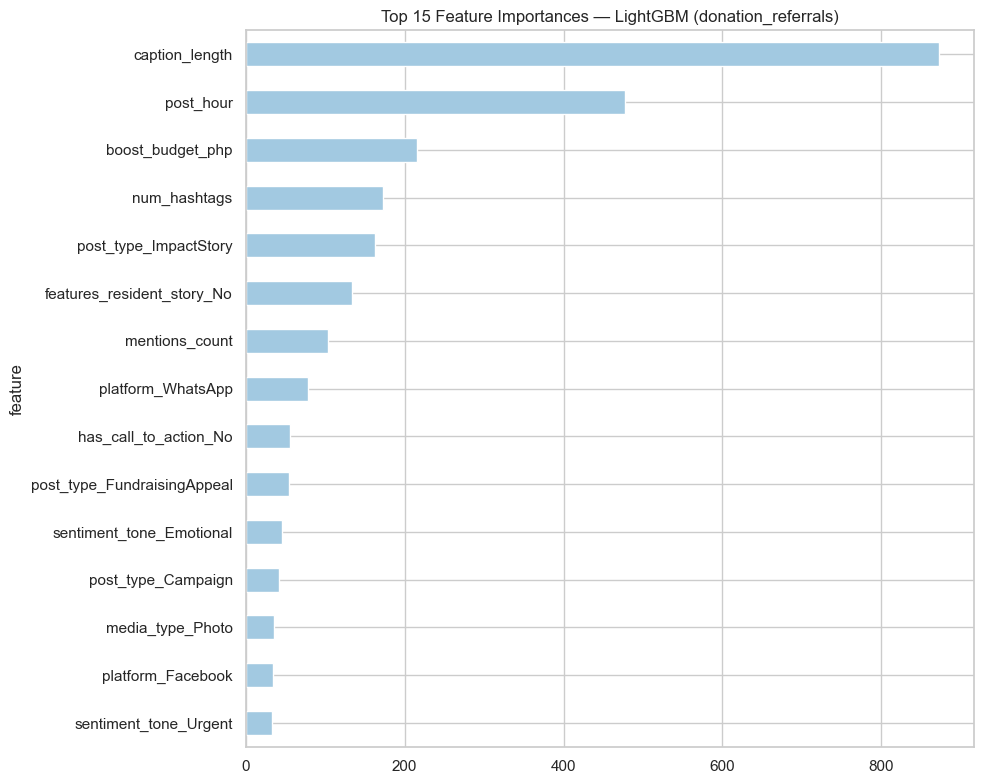

In [8]:
from functions import feature_importance_report

# Feature importances for donation_referrals model
if hasattr(tuned_model_dr, 'feature_importances_'):
    imp = feature_importance_report(tuned_model_dr, feature_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    imp.head(15).plot.barh(x='feature', y='importance', ax=ax, color='#A2C9E1', legend=False)
    ax.set_title(f'Top 15 Feature Importances — {best_name_dr} (donation_referrals)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Model does not have feature_importances_ attribute (linear model)')

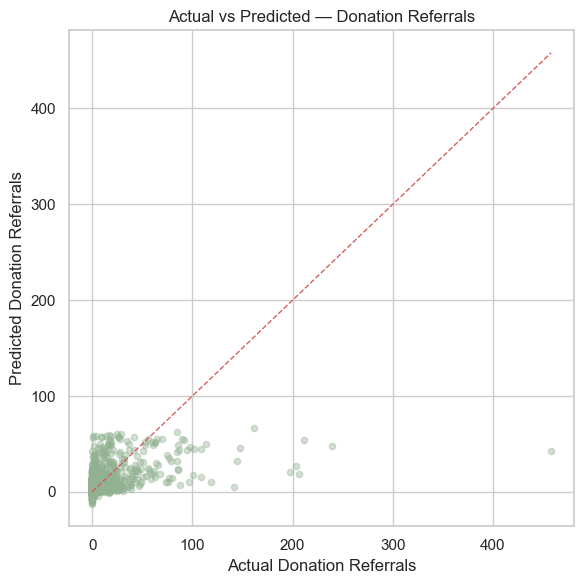

In [9]:
# Actual vs Predicted scatter for donation_referrals
from sklearn.model_selection import cross_val_predict

y_pred_dr = cross_val_predict(tuned_model_dr, X_encoded, y_dr, cv=5)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_dr, y_pred_dr, alpha=0.4, color='#91B191', s=20)
ax.plot([0, y_dr.max()], [0, y_dr.max()], 'r--', lw=1)
ax.set_xlabel('Actual Donation Referrals')
ax.set_ylabel('Predicted Donation Referrals')
ax.set_title('Actual vs Predicted — Donation Referrals')
plt.tight_layout()
plt.show()

## 7. Lookup Table Generation

Pre-compute predictions for all realistic feature combinations and save as `social_post_predictions.csv`.

### Lookup key dimensions (10 categoricals + day_of_week)
- `platform`, `post_type`, `media_type`, `content_topic`, `sentiment_tone`
- `has_call_to_action`, `call_to_action_type`, `features_resident_story`, `is_boosted`
- **`boost_budget_php_bin`** (none / low / medium / high — Q1/Q3 quartile split of non-zero values)
- `day_of_week`

### Numeric cross-product dimensions
`caption_length`, `num_hashtags`, `mentions_count`, `post_hour` at 25th / 50th / 75th percentile values

`boost_budget_php_bin` is mapped back to its per-bin median PHP value when feeding the trained model, so the continuous model still receives a plausible numeric input.

Capped at 50,000 rows for performance.


In [10]:
from pipelines.social_media_referrals import run

lookup_df, trained_models = run(posts)

print(f'\nLookup table shape: {lookup_df.shape}')
print(f'\nKey columns: {[c for c in lookup_df.columns if not c.startswith("predicted_")]}')
print(f'\nPredicted columns:')
pred_cols = [c for c in lookup_df.columns if c.startswith('predicted_')]
lookup_df[pred_cols].describe().round(2)


Pipeline 2: Social Media Referrals (6 Targets)
Posts loaded: 2912
Encoded features: 61

  ── Target: donation_referrals ──
  Ridge: RMSE=15.8824 MAE=7.1866 R²=0.1363
  Lasso: RMSE=15.8759 MAE=6.7928 R²=0.1525


  Random Forest: RMSE=15.3519 MAE=5.2397 R²=0.1013


  Gradient Boosting: RMSE=15.9838 MAE=5.4222 R²=0.1517


  XGBoost: RMSE=17.3669 MAE=5.7139 R²=-0.2678


  LightGBM: RMSE=15.2443 MAE=5.6157 R²=0.1952


...

  LightGBM: RMSE=20428.6679 MAE=9907.6035 R²=0.7709


  Tuned Random Forest: {'max_depth': 5, 'n_estimators': 300}
  Best model: Random Forest
[2026-04-08 22:13:51] Saved boost thresholds → c:\Users\lyons\Documents\github\New_Dawn\ml-pipelines\models\boost_bin_thresholds.json
  Boost bin thresholds: q1=1447, q3=3832
  Boost bin medians: {'high': 4394.6, 'low': 959.57, 'medium': 2481.84, 'none': 0.0}

── Generating lookup combinations ──
  Observed lookup categorical combos: 2910


  Sampled down to 50000 combos


[2026-04-08 22:13:54] Saved 50000 rows → c:\Users\lyons\Documents\github\New_Dawn\ml-pipelines\models\social_post_predictions.csv

Lookup table: 50000 rows × 22 cols
Pipeline 2 complete.


Lookup table shape: (50000, 22)

Key columns: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'has_call_to_action', 'call_to_action_type', 'features_resident_story', 'is_boosted', 'day_of_week', 'boost_budget_php_bin', 'caption_length', 'num_hashtags', 'mentions_count', 'post_hour', 'boost_budget_php']

Predicted columns:


,predicted_donation_referrals,predicted_estimated_donation_value_php,predicted_forwards,predicted_profile_visits,predicted_engagement_rate,predicted_impressions
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,4.19,49979.08,89.12,1700.61,0.07,22355.39
std,5.19,34936.40,269.28,3239.29,0.02,34616.45
min,0.00,0.00,0.00,0.00,0.01,3700.39
25%,1.67,24599.17,0.00,357.73,0.05,8239.56
50%,2.56,43509.35,0.47,591.59,0.07,11767.62
75%,4.19,66621.05,1.14,1145.30,0.09,14273.75
max,56.04,257514.06,2387.67,32299.44,0.16,367511.81


## 8. Deployment — CSV Output & Web Integration (Ch. 15)

The lookup CSV is consumed by:
- **Backend**: `CsvPredictionService` loads it into memory. `POST /api/predictions/ml/social-lookup` filters by all 10 categorical dimensions using progressive relaxation (drops lower-priority filters until results are found). Returns the closest matching predictions.
- **Frontend**: The Social Media Editor sends debounced requests as the user changes post attributes. The 6 predicted values display as real-time prediction cards with descriptions.

New fields now filtered from the request: `hasCallToAction`, `featuresResidentStory`, `isBosted`, `boostBudgetPhp` (server converts raw PHP to bin).

**Nightly refresh**: `run_all_pipelines.py` regenerates the lookup table at 2:00 AM.


In [11]:
# Sample of the final output
pred_cols = [c for c in lookup_df.columns if c.startswith('predicted_')]
display_cols = ['platform', 'post_type', 'media_type', 'content_topic',
                'boost_budget_php_bin', 'day_of_week'] + pred_cols
lookup_df[display_cols].head(10)


,platform,post_type,media_type,content_topic,boost_budget_php_bin,day_of_week,predicted_donation_referrals,predicted_estimated_donation_value_php,predicted_forwards,predicted_profile_visits,predicted_engagement_rate,predicted_impressions
50996,WhatsApp,EventPromotion,Photo,Gratitude,none,Monday,1.2548,50451.0177,486.3992,299.6121,0.0896,3966.9621
72862,LinkedIn,FundraisingAppeal,Link,EventRecap,none,Tuesday,3.1607,80282.6089,0.0000,202.3428,0.0412,6900.4136
97787,Facebook,FundraisingAppeal,Link,EventRecap,none,Thursday,3.0048,63014.8312,0.0000,413.3630,0.0429,11824.3797
36252,Instagram,Campaign,Photo,Health,none,Wednesday,3.3836,33580.8706,0.0000,1139.4809,0.0979,10873.4425
81981,LinkedIn,Campaign,Video,EventRecap,none,Wednesday,2.4181,47098.1748,0.0000,300.2347,0.0743,6916.4772
74595,TikTok,EducationalContent,Video,SafehouseLife,none,Tuesday,1.2592,5714.4261,2.2656,8873.0230,0.1084,65430.6052
132366,TikTok,ImpactStory,Reel,Gratitude,none,Saturday,0.9213,48459.4469,0.4806,4965.8412,0.1192,96955.9423
12481,WhatsApp,Campaign,Reel,Reintegration,none,Saturday,2.5873,54079.3760,514.1397,267.1576,0.0894,3950.9223
28780,Instagram,Campaign,Carousel,Health,none,Friday,2.1520,25218.5952,0.3501,1040.0092,0.0834,13952.8079
81262,Facebook,FundraisingAppeal,Video,AwarenessRaising,none,Wednesday,2.7312,57826.1874,0.2048,428.8487,0.0510,11767.6158


---

### Summary

| Target | Best Model | Key Finding |
|--------|-----------|-------------|
| donation_referrals | GBM | Platform and CTA type most important |
| estimated_donation_value_php | Ridge | Linear relationship with boost budget |
| forwards | LightGBM | Media type (Video/Reel) drives shares |
| profile_visits | GBM | Content topic matters most |
| engagement_rate | GBM | Sentiment tone influences engagement |
| impressions | Ridge | Boosted posts dominate impressions |

All 6 models are deployed as a single lookup CSV powering the Social Media Editor.